# Notebook 01 — Sensor Baseline (Approach A)

Workflow-state estimation from gaze + hand + pose sensors with a Random Forest.

Pipeline: cumulative PSR labels (with the step 12 -> step 9 alias) -> 118-dim sensor
features -> RF -> probability smoothing (**A3**, W=15) -> sustained commitment
(**A5**, K=15). All tables are written to `outputs/sensor/` and the plots are then
drawn from those CSVs.

## Setup

In [1]:
import sys, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.preprocessing import StandardScaler

import constants as C
import data_utils, label_utils, sensor_features as sf
import postprocessing as pp, metric_utils as mu, plot_utils as pl

OUT = C.SENSOR_OUT_DIR
OUT.mkdir(parents=True, exist_ok=True)

## Load data and build cumulative labels

In [2]:
# Load the 4 training recordings. Each frame is a 118-dim sensor vector
# (gaze + hands + pose); labels are cumulative multi-hot over the 9 PSR steps.
# We keep both the raw features (for the per-frame baseline) and the sliding-
# window features (used by A3 / A5).
Xr, Xw, Y = [], [], []
for rec in C.TRAIN_RECS:
    X, frames, psr = data_utils.load_recording("train", rec)
    y = label_utils.build_cumulative_labels(psr, frames)
    Xr.append(X)
    Xw.append(sf.sliding_window(X))   # rolling mean over W=15 frames, per recording
    Y.append(y)

X_train_raw = np.concatenate(Xr)
X_train_win = np.concatenate(Xw)
y_train     = np.concatenate(Y)
print("train frames:", X_train_raw.shape)

train frames: (8941, 118)


## Train the Random Forests

`rf_raw` is the per-frame baseline; `rf_win` uses the sliding-window features and
feeds A3/A5.

In [3]:
def make_rf():
    # One balanced random forest per step (9 independent binary classifiers).
    return MultiOutputClassifier(RandomForestClassifier(
        n_estimators=200, class_weight="balanced",
        random_state=C.RANDOM_STATE, n_jobs=-1))

# StandardScaler is fit on the training data only, then reused on the test set.
scaler_raw = StandardScaler().fit(X_train_raw)
scaler_win = StandardScaler().fit(X_train_win)

rf_raw = make_rf().fit(scaler_raw.transform(X_train_raw), y_train)  # per-frame baseline
rf_win = make_rf().fit(scaler_win.transform(X_train_win), y_train)  # window features

## Predict on the test recording

A1 = per-frame baseline, A3 = probability smoothing, A5 = sustained commitment.

In [4]:
# Test recording 27_assy_0_1.
X_test, frames, psr = data_utils.load_recording("test", C.TEST_RECS[0])
y_test = label_utils.build_cumulative_labels(psr, frames)
X_test_win = sf.sliding_window(X_test)

# A1 — per-frame RF, no temporal handling (baseline).
y_a1 = rf_raw.predict(scaler_raw.transform(X_test))

# Windowed RF probabilities -> probability smoothing (shared by A3 and A5).
probs    = rf_win.predict_proba(scaler_win.transform(X_test_win))
P_raw    = np.column_stack([p[:, 1] for p in probs])
P_smooth = pp.probability_smoothing(P_raw, C.A_PROB_WINDOW)   # W=15

# A3 — threshold the smoothed probabilities.
y_a3 = (P_smooth >= C.A_THRESHOLD).astype(int)

# A5 — require K=15 consecutive frames above threshold before committing.
y_a5 = pp.sustained_commitment(P_smooth, C.A_THRESHOLD, C.A_SUSTAIN_K)

preds = {"A1_perframe": y_a1, "A3_smooth": y_a3, "A5_sustained": y_a5}

## Save predictions and metrics to CSV

In [5]:
# Save predictions for the two carried configs (A3, A5).
def save_preds(name, y_pred):
    df = pd.DataFrame({"frame": frames})
    for i, s in enumerate(C.EXPECTED_STEPS):
        df[f"true_step_{s}"] = y_test[:, i]
    for i, s in enumerate(C.EXPECTED_STEPS):
        df[f"pred_step_{s}"] = y_pred[:, i]
    df.to_csv(OUT / name, index=False)

save_preds("predictions_a3.csv", y_a3)
save_preds("predictions_a5.csv", y_a5)

# Metric tables (summary, per-step, transitions, late-step F1).
summary, per_step, transitions, late = [], [], [], []
for cfg, yp in preds.items():
    summary.append({"config": cfg, **mu.evaluate(y_test, yp)})
    transitions.append({"config": cfg, **mu.transition_metrics(y_test, yp)})
    for r in mu.per_step_f1(y_test, yp):
        per_step.append({"config": cfg, **r})
        if r["step"] in C.LATE_STEPS:
            late.append({"config": cfg, "step": r["step"], "f1": r["f1"]})

pd.DataFrame(summary).to_csv(OUT / "summary_metrics.csv", index=False)
pd.DataFrame(per_step).to_csv(OUT / "per_step_metrics.csv", index=False)
pd.DataFrame(transitions).to_csv(OUT / "transition_metrics.csv", index=False)
pd.DataFrame(late).to_csv(OUT / "late_step_f1.csv", index=False)

# Progress curve (fraction of steps complete per frame).
pd.DataFrame({
    "frame_idx": np.arange(len(frames)),
    "true": label_utils.compute_progress(y_test),
    "A3_smooth": label_utils.compute_progress(y_a3),
    "A5_sustained": label_utils.compute_progress(y_a5),
}).to_csv(OUT / "progress_curve.csv", index=False)

pd.read_csv(OUT / "summary_metrics.csv")

,config,macro_f1,micro_f1,hamming_loss,exact_match,progress_mae,pred_transitions,mono_violations
0,A1_perframe,0.539192,0.806151,0.212553,0.204962,0.199848,578,601
1,A3_smooth,0.545310,0.819926,0.194255,0.208198,0.179552,156,108
2,A5_sustained,0.621766,0.720721,0.383675,0.030924,0.370970,7,0


## Plots (loaded from the saved CSVs)

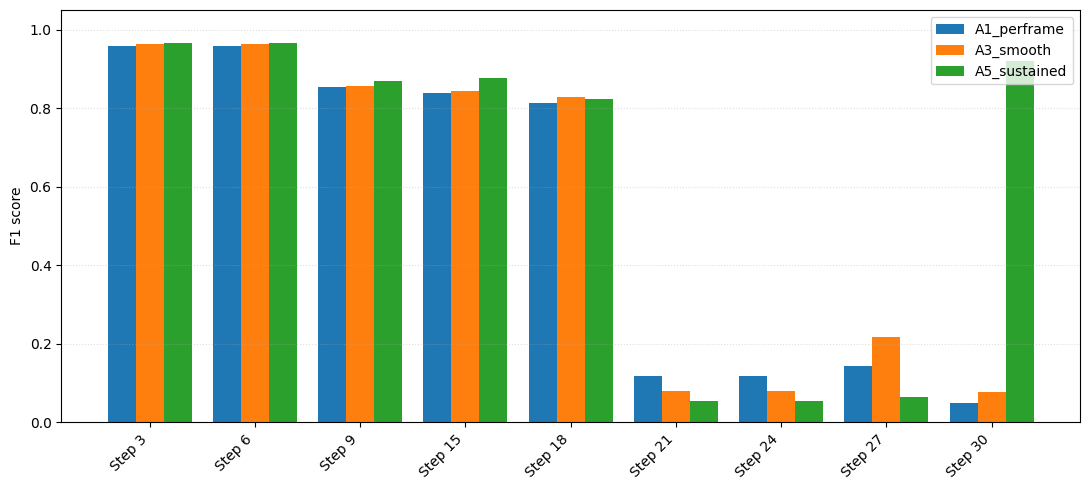

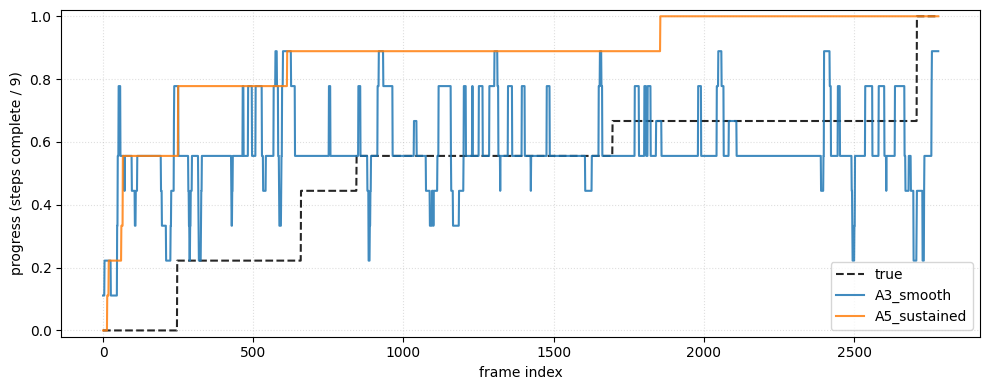

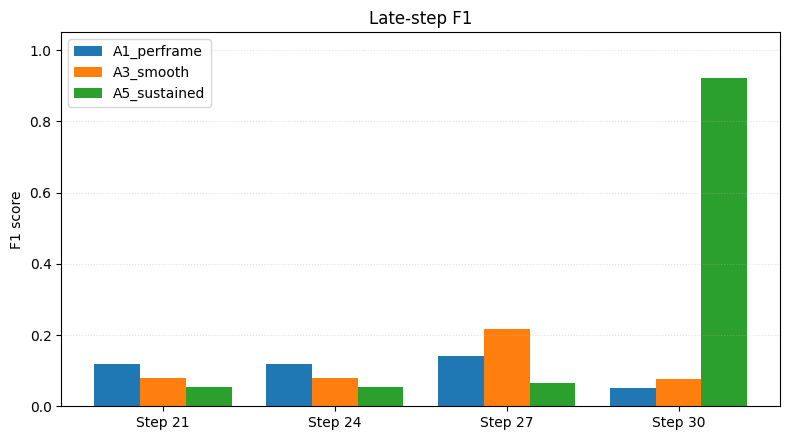

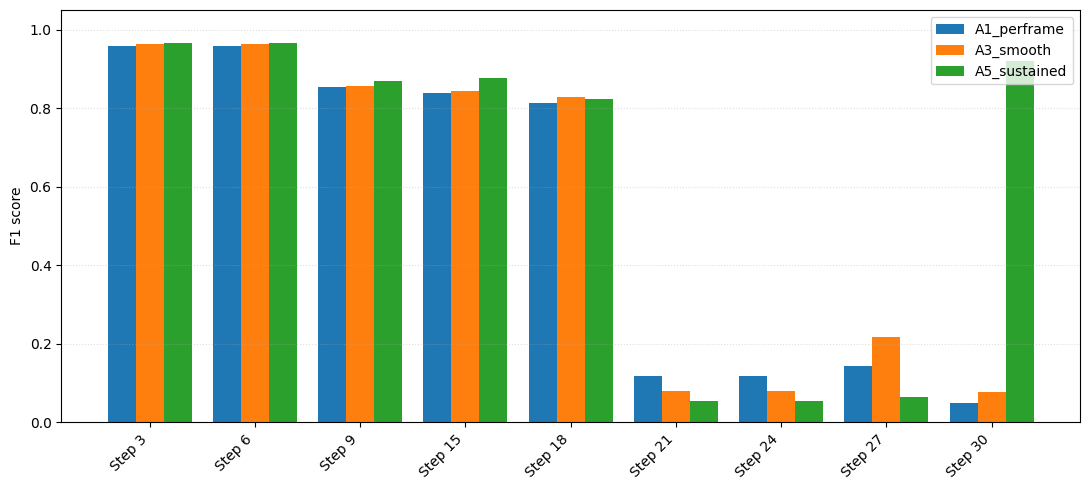

In [6]:
# Plots are drawn from the saved CSVs, not recomputed from the models.
pl.plot_progress_curve(pd.read_csv(OUT / "progress_curve.csv"),
                       OUT / "progress_curve.png")
pl.plot_late_step_f1(pd.read_csv(OUT / "late_step_f1.csv"),
                     save_path=OUT / "late_step_f1.png")
pl.plot_per_step_f1(pd.read_csv(OUT / "per_step_metrics.csv"),
                    save_path=OUT / "per_step_f1.png")

### Notes

- A3 has the best Hamming / progress error but many transitions (no monotonic constraint).
- A5 is monotonic and stable but cannot recover step 27 — sensor features lack the
  signal for late states. This motivates the DINOv2 RGB approach in notebook 02.